In [1]:
#import libraries
import cv2

import numpy as np
import os

from IPython.display import display
from PIL import Image

import matplotlib.pyplot as plt
%matplotlib inline

from time import time

In [7]:
import os
print(os.getcwd())
print(os.listdir('.'))

/
['proc', 'usr', 'media', 'sbin', 'etc', 'lib', 'opt', 'bin', 'sys', 'dev', 'boot', 'home', 'root', 'run', 'mnt', 'tmp', 'srv', 'var', 'lab1', '.ipynb_checkpoints', 'nvdli-nano', '.dockerenv', 'dst']


In [9]:
img3 = cv2.imread('./lab1/images/dice.png')
cv2.imshow('my image', img3)
cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.5.0) /opt/opencv/modules/highgui/src/window_gtk.cpp:641: error: (-2:Unspecified error) GTK backend is not available in function 'cvInitSystem'


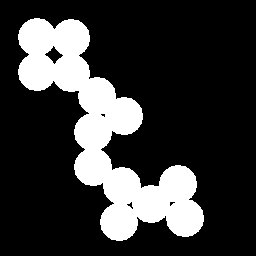

In [10]:
import cv2
import numpy as np
import os

from IPython.display import display
from PIL import Image
img3 = cv2.imread('./lab1/images/circles-2.png')
display(Image.fromarray(img3))

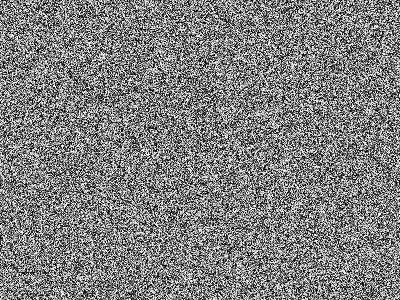

In [12]:
randomByteArray = bytearray(os.urandom(120000))
flatNumpyArray = np.array(randomByteArray)

grayImage = flatNumpyArray.reshape(300,400)
cv2.imwrite('./lab1/images/RandomGray.png', grayImage)
grayImage3 = cv2.imread('./lab1/images/RandomGray.png')

display(Image.fromarray(grayImage3))

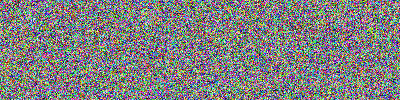

In [13]:
bgrImage = flatNumpyArray.reshape(100,400,3)
img = cv2.imwrite('./lab1/images/RandomColor.png', bgrImage)

img2 = cv2.imread('./lab1/images/RandomColor.png')
display(Image.fromarray(img2))

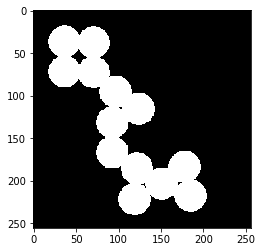

In [14]:
plt.imshow(img3)
plt.show()

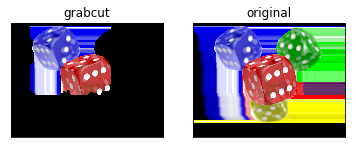

In [16]:
original = cv2.imread('./lab1/images/dice.png')
img = original.copy()
mask = np.zeros(img.shape[:2], np.uint8)

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1,65), np.float64)

rect = (100, 1, 421, 378)
cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

mask2 = np.where((mask==2) | (mask == 0), 0, 1).astype('uint8')
img = img*mask2[:,:,np.newaxis]

plt.subplot(121)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("grabcut")
plt.xticks([])
plt.yticks([])

plt.subplot(122)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("original")
plt.xticks([])
plt.yticks([])

plt.show()

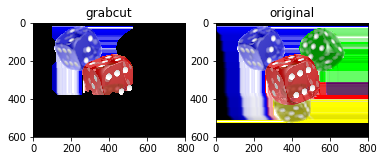

In [17]:
plt.subplot(121)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("grabcut")

plt.subplot(122)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("original")

plt.show()

In [19]:
import ipywidgets
from IPython.display import display

def bgr8_to_jpeg(value, quality=75):
    return bytes(cv2.imencode('.jpg', value)[1])

image_widget = ipywidgets.Image(format='jpg')

image_widget.value = bgr8_to_jpeg(original)

display(image_widget)

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

In [21]:
import pycuda.driver as drv
import pycuda.autoinit
from pycuda.compiler import SourceModule
import numpy as np
import cv2
import ipywidgets
from IPython.display import display

#convert image to jpg for display
def bgr8_to_jpeg(value, quality=75):
    return bytes(cv2.imencode('.jpg', value)[1])

In [25]:
# -*- coding: utf-8 -*-
"""
Created on Mon Aug 13 12:15:39 2018

@author: bhaumik
"""

#pass c code to perform work on GPU

mod = SourceModule \
    ( 
        '''
#include<stdio.h>
#define INDEX(a, b) a*256+b

__global__ void bgr2gray(float *d_result,float *b_img, float *g_img, float *r_img)
{
unsigned int idx = threadIdx.x+(blockIdx.x*(blockDim.x*blockDim.y));

unsigned int a = idx/256;
unsigned int b = idx%256;
d_result[INDEX(a, b)] = (0.299*r_img[INDEX(a, b)]+0.587*g_img[INDEX(a, b)]+0.114*b_img[INDEX(a, b)]);

}
  
  '''
      )
  
h_img = cv2.imread('./lab1/images/lena_color-1.tif',1)

# Extract and flatten the color channels
b_img = h_img[:, :, 0].reshape(65536).astype(np.float32)
g_img = h_img[:, :, 1].reshape(65536).astype(np.float32)
r_img = h_img[:, :, 2].reshape(65536).astype(np.float32)

# Prepare an empty array for the result
h_result = np.zeros_like(r_img)
h_result=r_img
#create instance of cuda function
bgr2gray = mod.get_function("bgr2gray")
#call pycuda function
bgr2gray(drv.Out(h_result), drv.In(b_img), drv.In(g_img),drv.In(r_img),block=(1024, 1, 1), grid=(64, 1, 1))

h_result=np.reshape(h_result,(256,256)).astype(np.uint8)
#display transformed image
image_widget = ipywidgets.Image(format='jpeg')
image_widget.value = bgr8_to_jpeg(h_result)
display(image_widget)
#original image
orgimage_widget = ipywidgets.Image(format='jpeg')
orgimage_widget.value = bgr8_to_jpeg(h_img)
display(orgimage_widget)

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

In [26]:
# -*- coding: utf-8 -*-
"""
Created on Mon Aug 13 12:15:39 2018

@author: bhaumik
"""


mod = SourceModule \
    (
        """
                   
__global__ void add_num(float *d_result, float *d_a, float *d_b,int N)
{
 int tid = threadIdx.x + blockIdx.x * blockDim.x;	
	while (tid < N)
    {
 d_result[tid] = d_a[tid] + d_b[tid];
 if(d_result[tid]>255)
 {
 d_result[tid]=255;
 }
 tid = tid + blockDim.x * gridDim.x;
}
    }
  
  """
      )
  
img1 = cv2.imread('./lab1/images/lena_color-1.tif',0)
img2 = cv2.imread('./lab1/images/circles-2.png',0)

#print a
h_img1 = img1.reshape(65536).astype(np.float32)
h_img2 = img2.reshape(65536).astype(np.float32)
N = h_img1.size
h_result=h_img1
add_img = mod.get_function("add_num")
add_img(drv.Out(h_result), drv.In(h_img1), drv.In(h_img2),np.uint32(N),block=(1024, 1, 1), grid=(64, 1, 1))

h_result=np.reshape(h_result,(256,256)).astype(np.uint8)

image_widget = ipywidgets.Image(format='jpeg')
image_widget.value = bgr8_to_jpeg(h_result)
display(image_widget)

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

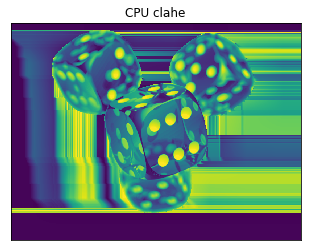

In [28]:
#CPU version
img = cv2.imread("./lab1/images/dice.png", cv2.IMREAD_GRAYSCALE)

def plotImages(imgr):
    plt.imshow(imgr)
    plt.title("CPU clahe")
    plt.xticks([])
    plt.yticks([])
   
  

#contrast Limited Adaptive Histogram Equalization
clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))
imgr = clahe.apply(img)

plotImages(imgr)

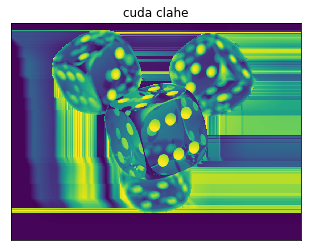

In [29]:
#reference https://learnopencv.com/getting-started-opencv-cuda-module/

def plotImages(img):
    plt.imshow(img)
    plt.title("cuda clahe")
    plt.xticks([])
    plt.yticks([])
  
img = cv2.imread("./lab1/images/dice.png", cv2.IMREAD_GRAYSCALE)
src = cv2.cuda_GpuMat()
src.upload(img)

clahe = cv2.cuda.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))
dst = clahe.apply(src, cv2.cuda_Stream.Null())

result = dst.download()

plotImages(imgr)

In [30]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}